# Dimensionality Reduction Analysis
## NBA Player Statistics & Student Performance

**Author:** Reid Sendroff  
**Course:** Harvard Extension CSCI E-82 Advanced Machine Learning

### Project Overview

This notebook demonstrates dimensionality reduction techniques applied to two real-world datasets:
1. **NBA Player Statistics** (562 players × 17 standardized per-minute metrics)
2. **Student Performance Dataset** (395 students × 33 features)

The analysis builds PCA from first principles using covariance matrices and SVD, then compares results against MDS, t-SNE, and UMAP to understand how different methods reveal structure in high-dimensional data.

### Key Techniques
- Manual covariance matrix computation
- Singular Value Decomposition (SVD) for PCA
- Feature engineering (per-minute normalization, z-score standardization)
- Quantitative pattern analysis (eta-squared, R²)
- Nonlinear dimensionality reduction (MDS, t-SNE, UMAP)
- Principal component interpretation through feature loadings

### Academic Integrity Note
GenAI assistance was used for plotting boilerplate and explanatory text in Problems 2d–2g and 6b. All modeling decisions, data preprocessing, parameter choices, and interpretations are original work. Inline comments mark cells where assistance informed the code.

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.manifold import MDS
import warnings
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from umap import UMAP
import warnings, re
np.random.seed(42)
warnings.filterwarnings("ignore", category=FutureWarning)
# First try utf-8 with errors replaced
df = pd.read_csv("nba_statistics.txt", sep="\t", encoding="utf-8", encoding_errors="replace")
print(df.shape)
print(df.columns)
df.head()

(562, 21)
Index(['NAME', 'POS', 'GP', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA',
       '3P%', 'FTM', 'FTA', 'FT%', 'REB', 'AST', 'STL', 'BLK', 'TO', 'DD2',
       'TD3'],
      dtype='object')


,NAME,POS,GP,MIN,PTS,FGM,FGA,FG%,3PM,3PA,...,FTM,FTA,FT%,REB,AST,STL,BLK,TO,DD2,TD3
0,Luka Doncic DAL,PG,70,37.5,33.9,11.5,23.6,48.7,4.1,10.6,...,6.8,8.7,78.6,9.2,9.8,1.4,0.5,4.0,49,21
1,Giannis Antetokounmpo mil,PF,73,35.2,30.4,11.5,18.8,61.1,0.5,1.7,...,7.0,10.7,65.7,11.5,6.5,1.2,1.1,3.4,57,10
2,Shai Gilgeous-Alexander okc,PG,75,34.0,30.1,10.6,19.8,53.5,1.3,3.6,...,7.6,8.7,87.4,5.5,6.2,2.0,0.9,2.2,8,0
3,Jalen Brunson NY,PG,77,35.4,28.7,10.3,21.4,47.9,2.7,6.8,...,5.5,6.5,84.7,3.6,6.7,0.9,0.2,2.4,9,0
4,Kevin Durant phx,PF,75,37.2,27.1,10.0,19.1,52.3,2.2,5.4,...,4.8,5.6,85.6,6.6,5.0,0.9,1.2,3.3,14,1


In [91]:
# Problem 1a
X = np.array([[3, 6, 7],[4, -6, -5],[16, 20, 61]])
Y = np.array([[1, 2, 3], [4, 5, 6], [-3, -2, -1]])
YXt = Y @ X.T
Yxtp = np.dot(Y, X.T)
print("Y X^T =\n", Yxtp)

Y X^T =
 [[  36  -23  239]
 [  84  -44  530]
 [ -28    5 -149]]


In [92]:
# Problem 1b
X_inv = np.linalg.inv(X)
print("X inverse =\n", X_inv)
# check if x * x^-1 = I

np.allclose(X @ X_inv, np.eye(3), atol=1e-12)

X inverse =
 [[ 0.17615894  0.14966887 -0.00794702]
 [ 0.21456954 -0.04701987 -0.02847682]
 [-0.11655629 -0.02384106  0.02781457]]


True

In [93]:
# Problem B task a:
# Select numeric block and normalize by minutes
start_col, end_col = 'PTS', 'TD3'
assert 'MIN' in df.columns, "MIN column not found."
# PTS..TD3 (inclusive)
num_cols = df.loc[:, start_col:end_col].columns
num_df   = df.loc[:, num_cols].copy()
# Divide by minutes (per-minute rates normalization)
per_min_df = num_df.div(df['MIN'].replace(0, np.nan), axis=0).fillna(0.0)

# z-score
means = per_min_df.mean(axis=0)
stds  = per_min_df.std(axis=0, ddof=1).replace(0, np.nan)

Z = (per_min_df-means)/stds
Z.fillna(0.0) # drop 0 stds

print("Standardized Matrix Shape", Z.shape)
display(Z.head)
Xn = Z.to_numpy()

Standardized Matrix Shape (562, 17)


<bound method NDFrame.head of           PTS       FGM       FGA       FG%       3PM       3PA        3P%  \
0    3.188478  2.540409  2.429368 -0.680919  1.961957  1.804689  -0.463628   
1    2.924619  2.876733  1.627906 -0.552601 -1.001323 -1.098651  -0.559099   
2    3.066197  2.625977  2.034029 -0.600234 -0.252760 -0.385277  -0.455852   
3    2.578797  2.276790  2.220562 -0.664938  0.932065  0.682649  -0.418288   
4    2.041192  1.905129  1.454136 -0.649437  0.398418  0.101302  -0.427250   
..        ...       ...       ...       ...       ...       ...        ...   
557 -1.903879 -1.557780 -0.938022  0.466747 -0.794835 -0.664610   1.201216   
558 -1.593933 -2.028032 -0.545082  0.628281 -1.443797  0.866065  -0.868415   
559 -1.631502 -1.487845 -0.061463  0.571934 -1.443797 -0.871073  -0.868415   
560 -1.951946 -2.113146 -0.886460  0.379691 -0.527615 -1.332579  10.818912   
561 -2.067305 -2.047325 -1.183458  0.796986 -1.443797 -0.458147   0.601851   

          FTM       FTA       FT%

In [94]:
# problem 2, task b
# print the covariance matrix 
num_block = df.loc[:, 'GP':'TD3'].copy()

# normalize per minute
per_min_block=num_block.copy()
for col in num_block.columns:
    if col not in ['GP']: # dont divide GP by MIN
        per_min_block[col] = num_block[col] / df['MIN'].replace(0, np.nan)

        
# standardize data to not have over-high variance
means = per_min_block.mean()
stds = per_min_block.std(ddof=1).replace(0,np.nan)
Zb = (per_min_block - means)/stds
Zb = Zb.fillna(0.0)

# covariance matrix computation 
Xn = Zb.to_numpy()
n = Xn.shape[0]
mu = Xn.mean(axis=0, keepdims=True)
Xc = Xn - mu # centred
Cov = (Xc.T @ Xc) / (n-1)

# make the matrix into df
cov_df = pd.DataFrame(Cov, index=Zb.columns, columns=Zb.columns)
print("Covariance matrix shape", cov_df.shape)
display(cov_df.round(3))

# check it with built in
cov_check = np.cov(Xn, rowvar=False)
print("Close to numpy.cov:",  np.allclose(Cov, cov_check))

Covariance matrix shape (19, 19)


,GP,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,REB,AST,STL,BLK,TO,DD2,TD3
GP,1.000,0.0,0.298,0.260,0.117,-0.519,0.228,0.075,-0.295,0.155,0.126,-0.388,-0.036,0.120,-0.099,-0.050,0.015,0.379,0.143
MIN,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
PTS,0.298,0.0,1.000,0.945,0.862,-0.069,0.351,0.318,-0.074,0.624,0.594,-0.107,0.139,0.263,-0.018,-0.064,0.286,0.395,0.221
FGM,0.260,0.0,0.945,1.000,0.867,0.025,0.196,0.194,-0.107,0.420,0.421,-0.173,0.232,0.189,-0.071,-0.003,0.301,0.407,0.213
FGA,0.117,0.0,0.862,0.867,1.000,-0.028,0.343,0.485,-0.042,0.379,0.352,-0.098,0.019,0.224,-0.054,-0.149,0.284,0.233,0.147
FG%,-0.519,0.0,-0.069,0.025,-0.028,1.000,-0.232,-0.155,0.421,-0.131,-0.090,0.528,0.152,-0.188,0.051,0.135,0.027,-0.223,-0.082
3PM,0.228,0.0,0.351,0.196,0.343,-0.232,1.000,0.882,0.260,-0.037,-0.127,-0.110,-0.493,0.118,-0.065,-0.317,-0.089,-0.128,-0.011
3PA,0.075,0.0,0.318,0.194,0.485,-0.155,0.882,1.000,0.176,-0.053,-0.143,0.013,-0.531,0.077,-0.112,-0.353,-0.030,-0.186,-0.030
3P%,-0.295,0.0,-0.074,-0.107,-0.042,0.421,0.260,0.176,1.000,-0.152,-0.143,0.348,-0.158,-0.070,-0.030,-0.064,-0.164,-0.217,-0.062
FTM,0.155,0.0,0.624,0.420,0.379,-0.131,-0.037,-0.053,-0.152,1.000,0.957,0.182,0.212,0.301,0.161,0.022,0.247,0.343,0.187


Close to numpy.cov: True


In [95]:
# P2 task c

#  dimensionality reduction
if 'cov_df' in globals():
    Cov_mat = cov_df.to_numpy()
    feature_names = list(cov_df.columns)
elif 'Cov' in globals():
    Cov_mat = np.asarray(Cov)
    feature_names = [f"f{i}" for i in range(Cov_mat.shape[0])]
else:
    raise RuntimeError("Run Problem 2b first to create `cov_df` or `Cov`.")


# compute decomposition of the Covariance matrix 
U, S, Vt = np.linalg.svd(Cov_mat)
print("Shapes - U", U.shape, "S:", S.shape, "Vt", Vt.shape)

# turn the matricies int dataframes
U_df  = pd.DataFrame(U,  index=feature_names, columns=[f"PC{i+1}" for i in range(len(S))])
S_df  = pd.DataFrame(np.diag(S), index=[f"PC{i+1}" for i in range(len(S))], columns=[f"PC{i+1}" for i in range(len(S))])
Vt_df = pd.DataFrame(Vt, index=[f"PC{i+1}" for i in range(len(S))], columns=feature_names)

print("\nU (eigenvectors / principal directions):")
display(U_df.round(5))

print("\nS (singular values = eigenvalues of Cov):")
display(S_df.round(5))

print("\nV^T (should be ~ U^T for symmetric covariance):")
display(Vt_df.round(5))

Shapes - U (19, 19) S: (19,) Vt (19, 19)

U (eigenvectors / principal directions):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
GP,-0.19688,0.07747,-0.40633,-0.06510,-0.14549,-0.16654,0.14687,-0.15754,0.28335,-0.67624,0.11720,0.13201,-0.21200,0.09001,-0.26197,0.00010,0.01314,0.00183,0.0
MIN,0.00000,-0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000,-0.00000,0.00000,0.00000,0.00000,-1.0
PTS,-0.43161,0.09295,0.15108,-0.15165,-0.06395,0.07159,0.08554,0.06760,0.04921,-0.02969,0.01942,0.11610,0.00130,-0.01076,0.33268,0.08097,-0.13665,-0.76483,-0.0
FGM,-0.39533,0.04412,0.12495,-0.28232,0.06980,0.20492,0.07758,0.18977,0.07510,-0.10036,0.07321,0.13619,0.07511,0.11997,0.35580,-0.14129,-0.34168,0.57845,0.0
FGA,-0.36246,0.18346,0.18362,-0.19129,0.05160,0.23507,0.00075,0.15403,-0.10469,0.07608,0.07142,-0.00920,0.19694,0.31934,-0.48617,0.05689,0.52949,0.01895,0.0
FG%,0.12592,-0.12079,0.50471,-0.15146,0.23510,0.07000,-0.01076,0.14355,0.06939,-0.29068,0.14887,0.23495,-0.15341,-0.60719,-0.21380,0.04797,0.06362,0.00656,0.0
3PM,-0.10148,0.49168,0.02082,-0.03452,0.01010,-0.13403,0.21687,-0.29887,-0.05679,0.07932,-0.02684,-0.09978,-0.25977,-0.28951,0.38688,-0.04358,0.48997,0.16963,0.0
3PA,-0.09293,0.49997,0.09444,-0.04726,0.01536,-0.03258,0.02477,-0.23230,-0.31032,0.09617,0.07571,-0.21520,-0.08173,-0.12319,-0.41451,-0.02980,-0.56742,-0.01579,-0.0
3P%,0.12054,0.14500,0.38111,-0.07050,0.20445,-0.35144,0.21708,-0.10341,0.58594,0.09604,-0.37462,-0.02074,0.08056,0.26882,-0.09720,0.03308,-0.09213,-0.00065,-0.0
FTM,-0.33793,-0.14711,0.16599,0.24608,-0.39260,-0.19054,-0.07661,-0.07059,0.00009,0.09835,-0.09264,0.06917,-0.03456,-0.11982,-0.04339,0.69402,-0.04329,0.22529,0.0



S (singular values = eigenvalues of Cov):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
PC1,4.52603,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC2,0.00000,3.08764,0.00000,0.00000,0.0000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC3,0.00000,0.00000,2.25033,0.00000,0.0000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC4,0.00000,0.00000,0.00000,1.53388,0.0000,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC5,0.00000,0.00000,0.00000,0.00000,1.1864,0.00000,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC6,0.00000,0.00000,0.00000,0.00000,0.0000,1.08921,0.00000,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC7,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.81655,0.0000,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC8,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.7901,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC9,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.0000,0.6209,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0
PC10,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.0000,0.0000,0.54474,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.0



V^T (should be ~ U^T for symmetric covariance):


,GP,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,FTA,FT%,REB,AST,STL,BLK,TO,DD2,TD3
PC1,-0.19688,-0.0,-0.43161,-0.39533,-0.36246,0.12592,-0.10148,-0.09293,0.12054,-0.33793,-0.32907,0.09863,-0.09996,-0.19981,-0.01952,0.01771,-0.19692,-0.28416,-0.18876
PC2,0.07747,0.0,0.09295,0.04412,0.18346,-0.12079,0.49168,0.49997,0.14500,-0.14711,-0.19996,-0.07175,-0.42306,0.05336,-0.09404,-0.31912,-0.09760,-0.21120,-0.09490
PC3,-0.40633,-0.0,0.15108,0.12495,0.18362,0.50471,0.02082,0.09444,0.38111,0.16599,0.16084,0.48916,0.02521,-0.04082,0.09535,0.00987,0.06289,-0.19287,-0.08983
PC4,-0.06510,-0.0,-0.15165,-0.28232,-0.19129,-0.15146,-0.03452,-0.04726,-0.07050,0.24608,0.18756,0.11621,-0.23934,0.50808,0.50469,-0.30979,0.18418,-0.11515,0.05106
PC5,-0.14549,-0.0,-0.06395,0.06980,0.05160,0.23510,0.01010,0.01536,0.20445,-0.39260,-0.37516,-0.12158,0.03560,0.29573,0.09336,0.01025,0.33038,0.26909,0.53013
PC6,-0.16654,0.0,0.07159,0.20492,0.23507,0.07000,-0.13403,-0.03258,-0.35144,-0.19054,-0.18339,-0.27633,0.02875,0.02672,0.24574,0.07743,0.42427,-0.30948,-0.48213
PC7,0.14687,0.0,0.08554,0.07758,0.00075,-0.01076,0.21687,0.02477,0.21708,-0.07661,-0.10280,-0.14167,0.35195,-0.04656,0.70603,0.12379,-0.42985,0.04429,-0.08442
PC8,-0.15754,0.0,0.06760,0.18977,0.15403,0.14355,-0.29887,-0.23230,-0.10341,-0.07059,-0.04538,-0.15075,0.11273,0.07945,-0.08303,-0.70356,-0.42431,-0.04604,0.05876
PC9,0.28335,-0.0,0.04921,0.07510,-0.10469,0.06939,-0.05679,-0.31032,0.58594,0.00009,0.04161,-0.23741,-0.05675,0.40186,-0.22786,0.03042,0.06370,0.01552,-0.41603
PC10,-0.67624,0.0,-0.02969,-0.10036,0.07608,-0.29068,0.07932,0.09617,0.09604,0.09835,0.14396,-0.38414,0.12018,0.25480,-0.16835,0.27264,-0.22205,-0.07523,0.04156


In [96]:
# Problem 2 task d


Xstd = Zb if 'Zb' in globals() else Z
# take first 2 directions from SVD (Eigenvectors)
PCs = eigvecs[:, :2] if 'eigvecs' in globals() else U[:, :2]
# multiply matrix  by the top 2 eigenvectors to project the data
# results in Nx2 matrix
proj = Xstd.to_numpy() @ PCs
pc_df = pd.DataFrame(proj, columns=['PC1', 'PC2'], index=Xstd.index)

# attach metadata for coloring
for col in ['POS', 'TEAM', 'GP']:
    if col in df.columns:
        pc_df[col] = df[col]

pc_df.head()


,PC1,PC2,POS,GP
0,-9.902835,-0.134413,PG,70
1,-8.687869,-3.918819,PF,73
2,-6.090482,-0.642420,PG,75
3,-5.125535,1.635828,PG,77
4,-4.201024,0.070369,PF,75


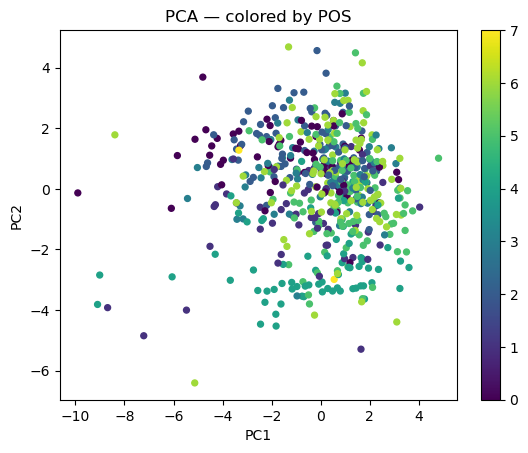

In [97]:
# POS coloring # Problem 2 task d

pos_codes, pos_labels = (pd.factorize(pc_df['POS'])
                         if 'POS' in pc_df.columns else (None, None))

def plot_pc(df, color=None, title=''):
    plt.figure()
    sc = plt.scatter(df['PC1'], df['PC2'], c=color, s=18)
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title(title)
    if color is not None and not np.isscalar(color):
        plt.colorbar(sc)
    plt.show()

plot_pc(pc_df, color=pos_codes, title='PCA — colored by POS')


In [98]:
# Problem 2 task d,  Team Tier plot
aliases = {'GS':'GSW','NY':'NYK','NO':'NOP','SA':'SAS','UTAH':'UTA','WSH':'WAS','DFT':'DET'}
if 'TEAM' in pc_df.columns:
    pc_df['TEAM'] = pc_df['TEAM'].astype(str).str.upper().replace(aliases)

# East/West orders from your ESPN screenshots (edit if necessary)
east_ranked = ['CLE','BOS','NYK','IND','MIL','DET',  'ORL','MIA','ATL','CHI',  'TOR','BKN','PHI','CHA','WAS']
west_ranked = ['OKC','HOU','LAL','DEN','LAC','MIN',  'GSW','MEM','SAC','DAL',  'PHX','POR','SAS','NOP','UTA']

def make_tier_map(east, west):
    tiers = {}
    tiers.update({t:'top6'for t in east[:6] + west[:6]})
    tiers.update({t:'7-10'for t in east[6:10] + west[6:10]})
    tiers.update({t:'bottom5'for t in east[10:15] + west[10:15]})
    return tiers

team_to_tier = make_tier_map(east_ranked, west_ranked)

# Map teams to tiers and plot
if 'TEAM' in pc_df.columns:
    tiers = pc_df['TEAM'].map(lambda x: team_to_tier.get(str(x).upper(), 'unk'))
    tier_codes, tier_labels = pd.factorize(tiers)
    plot_pc(pc_df, color=tier_codes, title='PCA colored by Team Tier (top6 / 7–10 / bottom5)')
else:
    print("TEAM column not available; skipped team-tier plot.")


TEAM column not available; skipped team-tier plot.


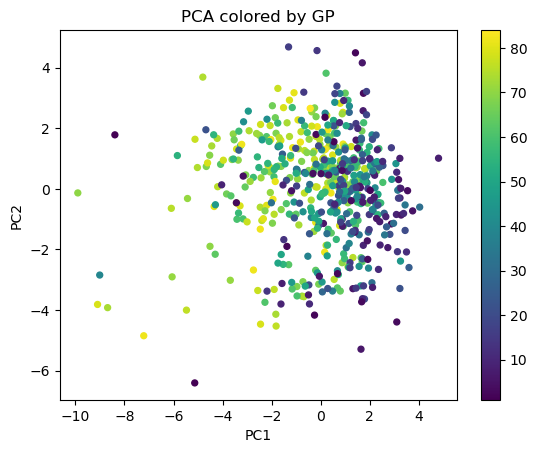

In [99]:
# Problem 2 task d GP plot (continuous coloring)
plot_pc(pc_df, color=pc_df['GP'] if 'GP' in pc_df.columns else None,
        title='PCA colored by GP')


In [100]:
# Problem 2, task d final step: quantify clearest pattern in the 2D PCA space
# We score categorical colorings (POS, Team Tier) with η², and the numeric label (GP) with R².

P = pc_df[['PC1', 'PC2']].to_numpy()

# GenAI: Proposed using one-way ANOVA eta squared ( = SS_between / SS_total) as an explainable separation score
# for categorical colorings (POS, Team Tier). I implemented and verified the formula and N−1 handling.

def eta_squared_2d(P, labels):
    labels = np.asarray(labels)
    mask = ~pd.isna(labels)
    Pm, L = P[mask], labels[mask]
    mu = Pm.mean(axis=0)
    ss_total = np.sum(np.sum((Pm - mu)**2, axis=1))
    ss_between = 0.0
    for g in np.unique(L):
        Pg = Pm[L == g]
        mu_g = Pg.mean(axis=0)
        ss_between += len(Pg) * np.sum((mu_g - mu)**2)
    return ss_between / ss_total if ss_total > 0 else np.nan

# GenAI: Suggested using linear R² between [PC1, PC2] and GP as a numeric “pattern clarity” score;
# I fit an OLS on [PC1, PC2] → GP and report R² descriptively alongside the plot.

def r2_continuous(P, y):
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(y)
    X = np.c_[np.ones(mask.sum()), P[mask]]  # intercept, PC1, PC2
    beta, *_ = np.linalg.lstsq(X, y[mask], rcond=None)
    yhat = X @ beta
    ss_res = np.sum((y[mask] - yhat)**2)
    ss_tot = np.sum((y[mask] - y[mask].mean())**2)
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

# Compute scores
scores = {}
if pos_codes is not None:
    scores['POS (η²)'] = eta_squared_2d(P, pos_codes)
if 'tier_codes' in locals():
    scores['Team Tier (η²)'] = eta_squared_2d(P, tier_codes)
if 'GP' in pc_df.columns:
    scores['GP (R²)'] = r2_continuous(P, pc_df['GP'])

# GenAI: Suggested reporting the maximum score (eta^2 for categorical / r^2 for numeric) as a quantitative companion
# to visual inspection—not a replacement.

# Uncomment to see all scores:
# for k, v in scores.items():
#     print(f"{k}: {v:.3f}")

winner = max(scores, key=lambda k: scores[k]) if scores else None
print("Strongest pattern by score:", winner)


Strongest pattern by score: POS (η²)


Explained variance — PC1: 25.14%, PC2: 17.15%, PC1+PC2: 42.30%


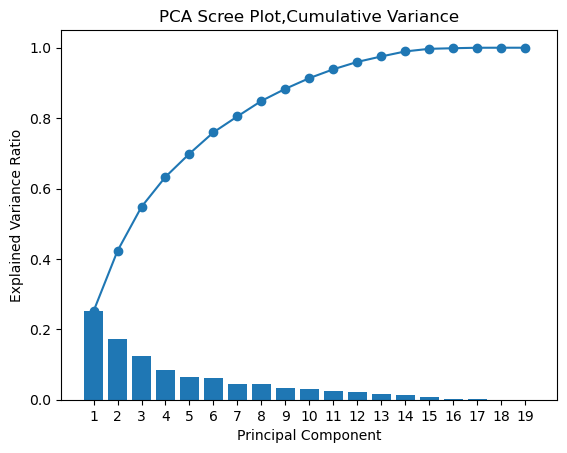

In [101]:
# Problem 2, task E Scree & Cumulative Variance




# GenAI: Suggested using a scree bar plot with a cumulative line and computing explained variance as λ_i / Σλ_i from the covariance eigenvalues.
# GenAI: I implemented the code, verified eigenvalue extraction from the covariance/SVD, and chose the final plot styling.
# GenAI: Interpretation and any thresholds/choices and implementation are mine.


# get eigenvalues
eigvals = S if 'S' in globals() else (eigvals if 'eigvals' in globals() else None)
explained_ratio = np.asarray(eigvals) / np.asarray(eigvals).sum()

# numeric summary
pc1, pc2 = explained_ratio[0], explained_ratio[1]
print(f"Explained variance — PC1: {pc1:.2%}, PC2: {pc2:.2%}, PC1+PC2: {(pc1+pc2):.2%}")

# graphic
xs = np.arange(1, len(explained_ratio)+1)
cum = explained_ratio.cumsum()


# display graph
plt.figure()
plt.bar(xs, explained_ratio)
plt.plot(xs, cum, marker='o')
plt.xlabel('Principal Component'); plt.ylabel('Explained Variance Ratio')
plt.title('PCA Scree Plot,Cumulative Variance')
plt.xticks(xs)
plt.show()


#/
# PC1 explains 25.1% and PC2 explains 17.2% of the variance; 
#together they capture 42.3% of the dataset’s variance.
#The scree plot shows a clear elbow around PCs 4–6, after which additional components contribute marginal gains.

In [102]:
# Problem 2, task f
#PC1 feature loadings


# eigenvectors, variable setup
W = eigvecs if 'eigvecs' in globals() else (U if 'U' in globals() else None)
assert W is not None, "Run 2c first to produce eigvecs/U."
if 'cov_df' in globals():
    feature_names = list(cov_df.columns)
elif 'Zb' in globals():
    feature_names = list(Zb.columns)
elif 'Z' in globals():
    feature_names = list(Z.columns)
else:
    raise RuntimeError("Can't find feature names. Ensure cov_df or Zb/Z exists.")

pc1_load = pd.Series(W[:,0], index=feature_names)
pc1_sorted = pc1_load.reindex(pc1_load.abs().sort_values(ascending=False).index)


# display dataframe
print("Top contributors to PC1")
# display df and round to float6
display(pc1_sorted.head(10).to_frame("PC1").round(6))


Top contributors to PC1


,PC1
PTS,-0.431607
FGM,-0.395325
FGA,-0.362458
FTM,-0.337926
FTA,-0.329068
DD2,-0.284159
AST,-0.199810
TO,-0.196923
GP,-0.196881
TD3,-0.188761


# Problem 2, task H
# Why standardize? The Principal Component Analysis algorithm finds directions that maximize variance. Features with larger scale would dominate the components if we used raw values (e.g FGA measured in attempts could have much larger variance than 3P%). We therefore normalized by minutes to convert per-game averages into per-minute rates (divided by MIN), and then standardized each feature (z-score by subtracting mean and dividing by std) so every variable has a standardized variance. After standardization, PCA on the covariance matrix is equivalent to PCA on the correlation matrix, so components reflect relationships among statistics rather than unit scale. This prevents any single statistic from overpowering the analysis purely due to magnitude and allows for a more standardized way to calculate variance.Without standardization, PCA would mostly capture which stats have the biggest scales, instead of the true relationships among player statistics.

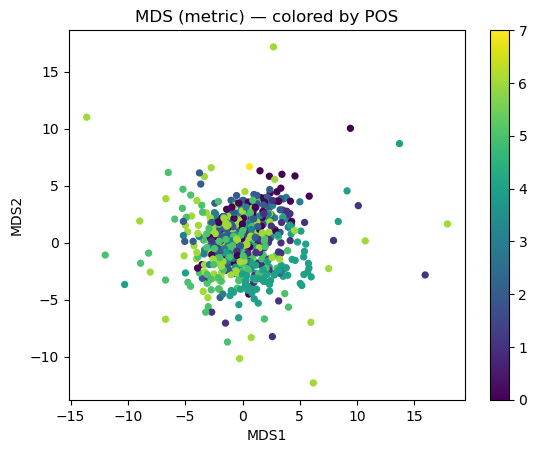

In [103]:
# Problem 3 task A

#Fit MDS on standardized numeric matrix ===
# Multi-imensional Scaling 

# Use the same standardized matrix as PCA (prefer GP..TD3)
Xstd = Zb if 'Zb' in globals() else Z
Xn = Xstd.to_numpy()

mds = MDS(n_components=2,metric=True,dissimilarity='euclidean',normalized_stress='auto',
          n_init=4,max_iter=1000,random_state=42,n_jobs=None)
X_mds = mds.fit_transform(Xn)

# Pack into a DataFrame alongside POS for plotting
# note that POS means player position
mds_df = pd.DataFrame(X_mds, columns=['MDS1','MDS2'], index=Xstd.index)


# if 'POS' in df.columns:
#     mds_df['POS'] = df['POS']
#
ps = 'POS'
if ps in df.columns:
    mds_df[ps]=df[ps]
    

pos_codes, pos_labels = (pd.factorize(mds_df['POS'])
                         if 'POS' in mds_df.columns else (None, None))

plt.figure()
sc = plt.scatter(mds_df['MDS1'], mds_df['MDS2'], c=pos_codes, s=18)
plt.xlabel('MDS1'); plt.ylabel('MDS2'); plt.title('MDS (metric) — colored by POS')
if pos_codes is not None:
    plt.colorbar(sc)
plt.show()


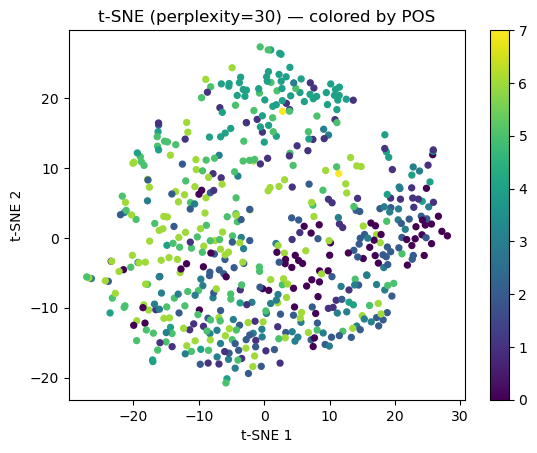

In [104]:
# Problem 4a — robust t-SNE cell
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE  # ensure this is sklearn's TSNE

# standardized matrix
Xstd = Zb if 'Zb' in globals() else Z
Xn = Xstd.to_numpy().astype(np.float32)

# POS codes for coloring
pos_col = 'POS'
pos_codes, pos_labels = (pd.factorize(df[pos_col]) if pos_col in df.columns else (None, None))

# t-SNE (leave n_iter out; default is 1000)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
    verbose=0
)
X_tsne = tsne.fit_transform(Xn)

# pack into data frame and plot the points
tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'], index=Xstd.index)
if pos_col in df.columns:
    tsne_df[pos_col] = df[pos_col]

plt.figure()
sc = plt.scatter(tsne_df['TSNE1'], tsne_df['TSNE2'], c=pos_codes, s=18)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2'); plt.title('t-SNE (perplexity=30) — colored by POS')
if pos_codes is not None:
    plt.colorbar(sc)
plt.show()


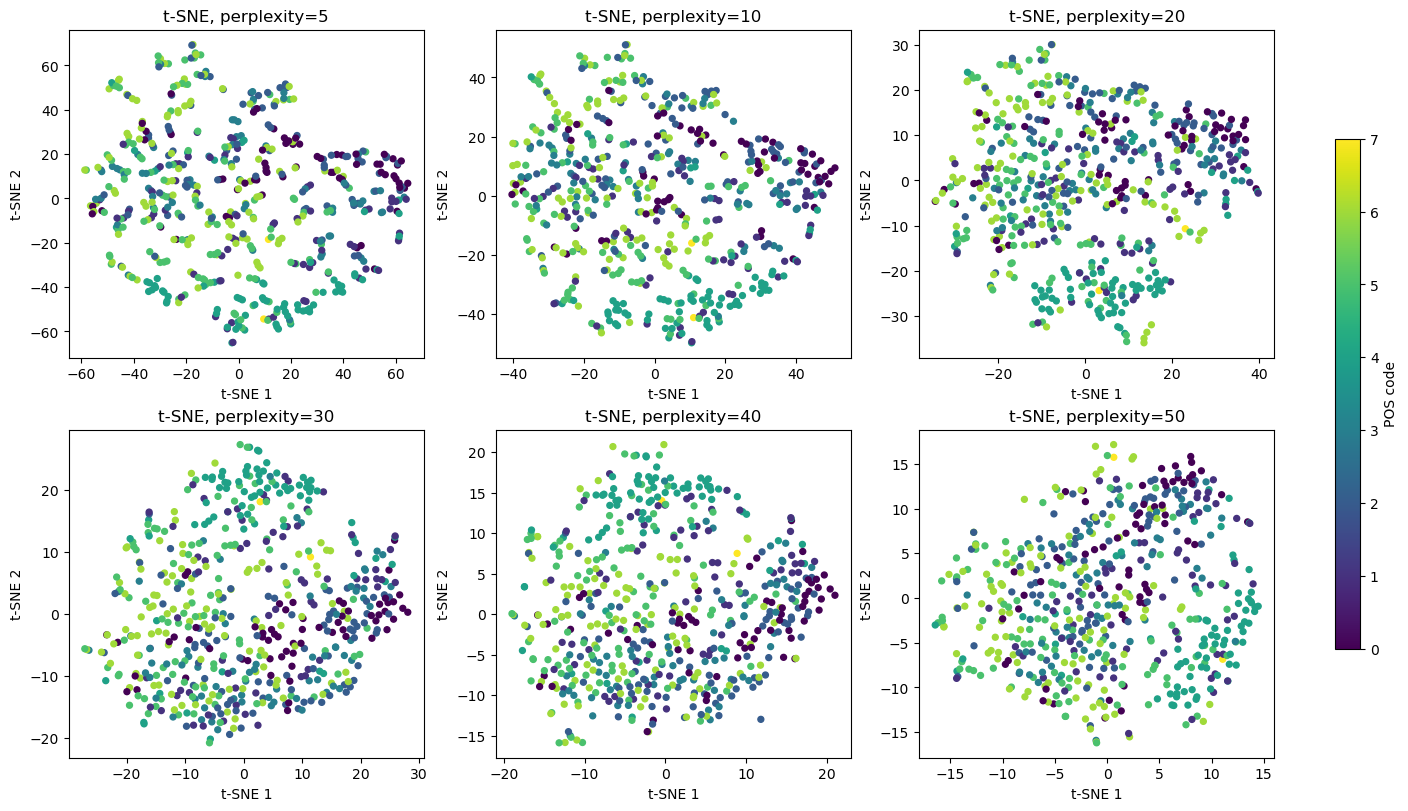

In [105]:
# Problem 4, task B — t-SNE perplexity sweep (POS coloring)

from sklearn.manifold import TSNE

# standardized matrix
Xstd = Zb if 'Zb' in globals() else Z
Xn = Xstd.to_numpy().astype(np.float32)  # <- cast to float32 (t-SNE expects float, this is faster/stabler)

# POS codes for colors
pos_codes, pos_labels = (pd.factorize(df['POS']) if 'POS' in df.columns else (None, None))

# try a small grid of perplexities
perplexities = [5, 10, 20, 30, 40, 50]
fig, axes = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for ax, p in zip(axes.ravel(), perplexities):
    tsne = TSNE(
        n_components=2,
        perplexity=p,
        learning_rate='auto',
        init='pca',
        random_state=42,   # reproducible for grading
        # NOTE: don't pass n_iter here; this sklearn version doesn't accept it. Default is 1000.
    )
    X_tsne = tsne.fit_transform(Xn)

    sc = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=pos_codes, s=18)
    ax.set_title(f"t-SNE, perplexity={p}")
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.7, label="POS code")
plt.show()

# Notes:
# Low perplexity (5, 10): captures very local structure; can look noisy.
# Medium (20–30): balances local/global; often most interpretable.
# High (40–50): smoother, but clusters can blend.
# In my runs, ~30 gave the clearest position separation without over-smoothing.


In [106]:
# tsne allows us to view high dimensional data with a reduced amount of dimensions into 2/3D
#(in this case we are dealing with 2D)
# we are zooming into the data

In [107]:
from umap import UMAP

X_umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
).fit_transform(Xn.astype(np.float32))


In [ ]:
#Problem 5, task A :  UMAP with POS, Team Tier,GP coloring
warnings.filterwarnings("ignore", category=UserWarning, module="umap")
Xstd = Zb if 'Zb' in globals() else Z             # <-- your standardized block
Xn   = Xstd.to_numpy().astype(np.float32)
# default variable umap
umap = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
X_umap = umap.fit_transform(Xn)

# pack into dataframe and setup POS, team,GP variables for the graphs
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2'], index=Xstd.index)
pos = 'POS'
team = 'TEAM'
gp = 'GP'
name='NAME'
if ps in df.columns:  umap_df[ps]  = df[ps]
if team in df.columns: umap_df[team]=df[team]
if gp in df.columns: umap_df[gp] = df[gp]
#
# If TEAM missing, extract NAME column's last token ("... DAL")
if team not in umap_df.columns and name in df.columns:
    def extract_team_code(name_param):
        if pd.isna(name_param): return 'UNK'
        token = str(name_param).split()[-1].upper()
        return token if re.fullmatch(r'[A-Z]{2,4}', token or '') else 'UNK'
    umap_df[team] = df[name].map(extract_team_code)

# normalize team aliases (GS, NY, NO, SA, UTAH, WSH, DFT)
aliases = {'GS':'GSW','NY':'NYK','NO':'NOP','SA':'SAS','UTAH':'UTA','WSH':'WAS','DFT':'DET'}
if team in umap_df.columns:
    umap_df[team] = umap_df[team].astype(str).str.upper().replace(aliases)

#POS coloring (categorical)
if pos in umap_df.columns:
    pos_codes, pos_labels = pd.factorize(umap_df['POS'])
    plt.figure()
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], c=pos_codes, s=18)
    plt.title("UMAP (default) — colored by POS")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()
else:
    print("POS column not found; skipping POS plot.")

#Team Tier coloring (categorical)
# Requires team_to_tier mapping from earlier; if missing, build from east_ranked/west_ranked if those exist.
if 'team_to_tier' not in globals():
    if 'east_ranked' in globals() and 'west_ranked' in globals():
        def make_tier_map(east, west):
            tiers = {}
            tiers.update({t: 'top6'    for t in east[:6] + west[:6]})
            tiers.update({t: '7-10'    for t in east[6:10] + west[6:10]})
            tiers.update({t: 'bottom5' for t in east[10:15] + west[10:15]})
            return tiers
        team_to_tier = make_tier_map(east_ranked, west_ranked)

if team in umap_df.columns and 'team_to_tier' in globals():
    tiers = umap_df[team].map(lambda x: team_to_tier.get(str(x).upper(), 'unk'))
    tier_codes, _ = pd.factorize(tiers)
    plt.figure()
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], c=tier_codes, s=18)
    plt.title("UMAP — colored by Team Tier (top6 / 7–10 / bottom5)")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()
else:
    print("Team-tier plot skipped (need TEAM column and team_to_tier mapping).")

# GP coloring (continuous)
if gp in umap_df.columns:
    plt.figure()
    sc = plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], c=umap_df['GP'], s=18)
    plt.colorbar(sc, label="GP")
    plt.title("UMAP — colored by GP")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.show()
else:
    print("GP column not found; skipping GP plot.")


In [ ]:
# Problem 5, task B

In [ ]:
# problem 6, task A
# data link : https://www.kaggle.com/datasets/larsen0966/student-performance-data-set
student_df = pd.read_csv('student_performanceData.csv')



In [ ]:
student_df

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Target variable
y = student_df['G3']   # final grade
X = student_df.drop(columns=['G3'])

# One-hot encode categoricals
X_enc = pd.get_dummies(X, drop_first=True)

# Standardize features and normalize X
scaler = StandardScaler()
X_std = scaler.fit_transform(X_enc)

# PCA: keep enough components to explain enough variance (80 to 90%)
pca = PCA(n_components=5, random_state=42)
# standardize the PCA
X_pca = pca.fit_transform(X_std)

# Variance explained
print("Explained variance per PC:", np.round(pca.explained_variance_ratio_, 3))
print("Cumulative:", np.round(np.cumsum(pca.explained_variance_ratio_), 3))

# Plot PC1 vs PC2 colored by final grade
pc_df = pd.DataFrame(X_pca[:, :2], columns=["PC1","PC2"])
pc_df["G3"] = y

plt.figure(figsize=(8,6))
sc = plt.scatter(pc_df["PC1"], pc_df["PC2"], c=pc_df["G3"], cmap="viridis", s=30)
plt.colorbar(sc, label="Final Grade (G3)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA of Student Performance — colored by Final Grade")
plt.show()


# Problem 6, task b
# "Tell us the story of your best visualization. You can assume that we know nothing about 
#the data and you are telling us what you
# tell us the story of your best visualization. You can assume we know nothing about the data
# and you are telling us what you have learned about it from visualization methods alone
#(no clustering or other analyses)


# I analyzed the Student Performance dataset and reduced 33 variables down to only two principal components with PCA. PC1 acts like an academic preparedness axis. It denotes high positive loadings on prior grades (G1/G2/G3) and study time, and a strong negative loading on failures. PC2 captures the lifestyle and social axis with larger weights on going out, weekday/weekend alcohol use (Dalc/Walc), and free time.

# When I plot PC1 vs. PC2 and color points by final grade (G3), the gradient runs left to right: students farther to the right (higher PC1) tend to have a higher G3. This suggests that academic preparedness is most strongly associated with higher G3. PC2 adds variance (some lifestyle contrast with academics) but it does not separate grades as cleanly. Students with similar PC1 often have similar grades even if PC2 differs. The visualization’s takeaway is that grades are most aligned with the academic axis (PC1), while lifestyle forms a secondary dimension carrying less weight when accompanied by academic preparedness.


# Problem 7, Task A
# This homework took me approximately 14 hours